In [1]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,GradientBoostingClassifier,
    AdaBoostClassifier,ExtraTreesClassifier,)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ( accuracy_score,classification_report,confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv(r"D:\DataMining\sonar_data.csv")
print(f"Shape: {df.shape}")
print(f"Classes: {df['target'].value_counts()}")

Shape: (208, 61)
Classes: target
M    111
R     97
Name: count, dtype: int64


In [3]:
X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target']) 

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.15, stratify=y, random_state=42)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
pca = PCA(n_components=8)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [6]:
models = {
    "SVM": SVC(probability=True, kernel='rbf', C=2, random_state=42),
    "Neural Network": MLPClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=120, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=120, learning_rate=0.12, max_depth=2,
        subsample=0.8, colsample_bytree=0.8, random_state=42,),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "AdaBoost": AdaBoostClassifier(n_estimators=120, learning_rate=0.1, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=120, max_depth=5, random_state=42),
}

In [7]:
results = []
print("PCA:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))
    print(f"{name}: {acc:.2f}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*60)

PCA:
SVM: 0.97
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.94      1.00      0.97        15

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32

Confusion Matrix:
 [[16  1]
 [ 0 15]]
------------------------------------------------------------
Neural Network: 0.91
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       1.00      0.80      0.89        15

    accuracy                           0.91        32
   macro avg       0.93      0.90      0.90        32
weighted avg       0.92      0.91      0.90        32

Confusion Matrix:
 [[17  0]
 [ 3 12]]
------------------------------------------------------------
Random Forest: 0.91
              precision    recall  f1-score   support

           0       0.89      0.94    

In [8]:
best_model, best_acc = sorted(results, key=lambda x: x[1], reverse=True)[0]
print(f"Best Model: {best_model}  //  Best Accuracy = {best_acc:.2f}")

Best Model: SVM  //  Best Accuracy = 0.97


In [9]:
sample = np.array([(0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,
                    0.2716,0.2374,0.1878,0.0983,0.0683,0.1503,0.1723,0.2339,0.1962,0.1395,
                    0.3164,0.5888,0.7631,0.8473,0.9424,0.9986,0.9699,1.0000,0.8630,0.6979,
                    0.7717,0.7305,0.5197,0.1786,0.1098,0.1446,0.1066,0.1440,0.1929,0.0325,
                    0.1490,0.0328,0.0537,0.1309,0.0910,0.0757,0.1059,0.1005,0.0535,0.0235,
                    0.0155,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031)])
sample = scaler.transform(sample)
sample = pca.transform(sample)

bestModel = models[best_model]
prediction = bestModel.predict(sample)
label = "Rock" if prediction[0] == 1 else "Mine"

print(f"Prediction: {label}")

Prediction: Mine


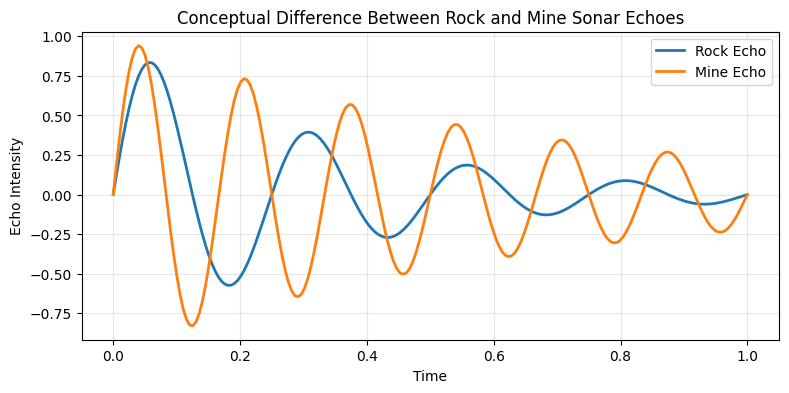

In [10]:
t = np.linspace(0, 1, 200)

rock_echo = np.sin(8 * np.pi * t) * np.exp(-3 * t)
mine_echo = np.sin(12 * np.pi * t) * np.exp(-1.5 * t)

plt.figure(figsize=(9, 4))
plt.plot(t, rock_echo, label="Rock Echo", linewidth=2)
plt.plot(t, mine_echo, label="Mine Echo", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Echo Intensity")
plt.title("Conceptual Difference Between Rock and Mine Sonar Echoes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


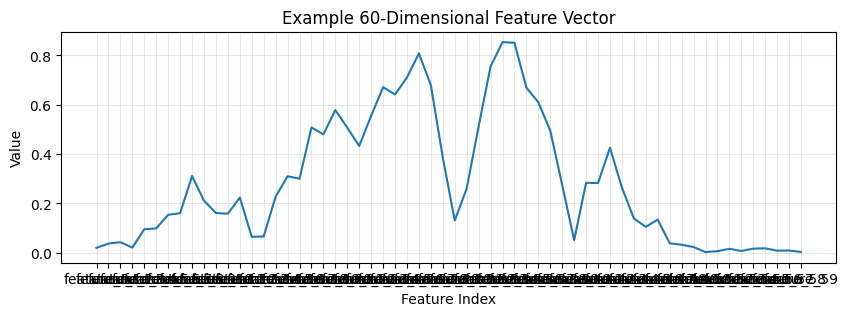

In [11]:
plt.figure(figsize=(10, 3))
plt.plot(X.iloc[0])
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.title("Example 60-Dimensional Feature Vector")
plt.grid(alpha=0.3)
plt.show()


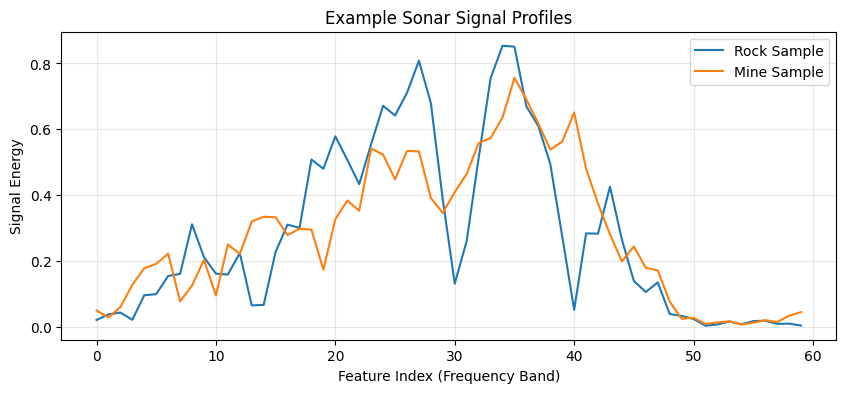

In [12]:
sample_rock = df[df["target"] == "R"].iloc[0, :-1].values
sample_mine = df[df["target"] == "M"].iloc[0, :-1].values

plt.figure(figsize=(10, 4))
plt.plot(sample_rock, label="Rock Sample")
plt.plot(sample_mine, label="Mine Sample")
plt.xlabel("Feature Index (Frequency Band)")
plt.ylabel("Signal Energy")
plt.title("Example Sonar Signal Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


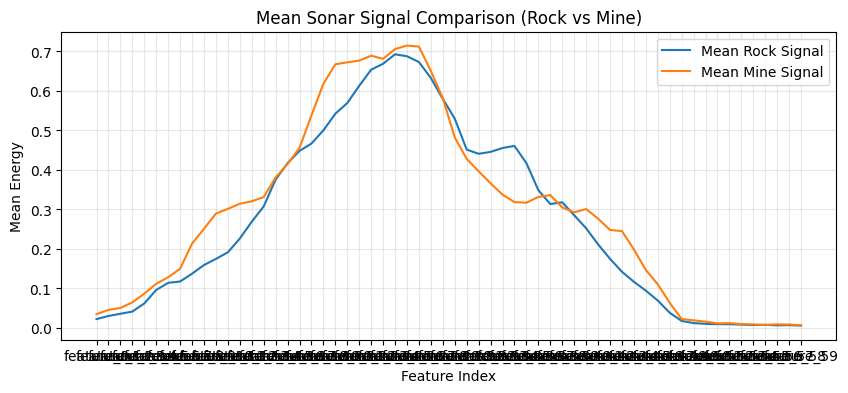

In [13]:
mean_rock = X[df["target"] == "R"].mean()
mean_mine = X[df["target"] == "M"].mean()

plt.figure(figsize=(10, 4))
plt.plot(mean_rock, label="Mean Rock Signal")
plt.plot(mean_mine, label="Mean Mine Signal")
plt.xlabel("Feature Index")
plt.ylabel("Mean Energy")
plt.title("Mean Sonar Signal Comparison (Rock vs Mine)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


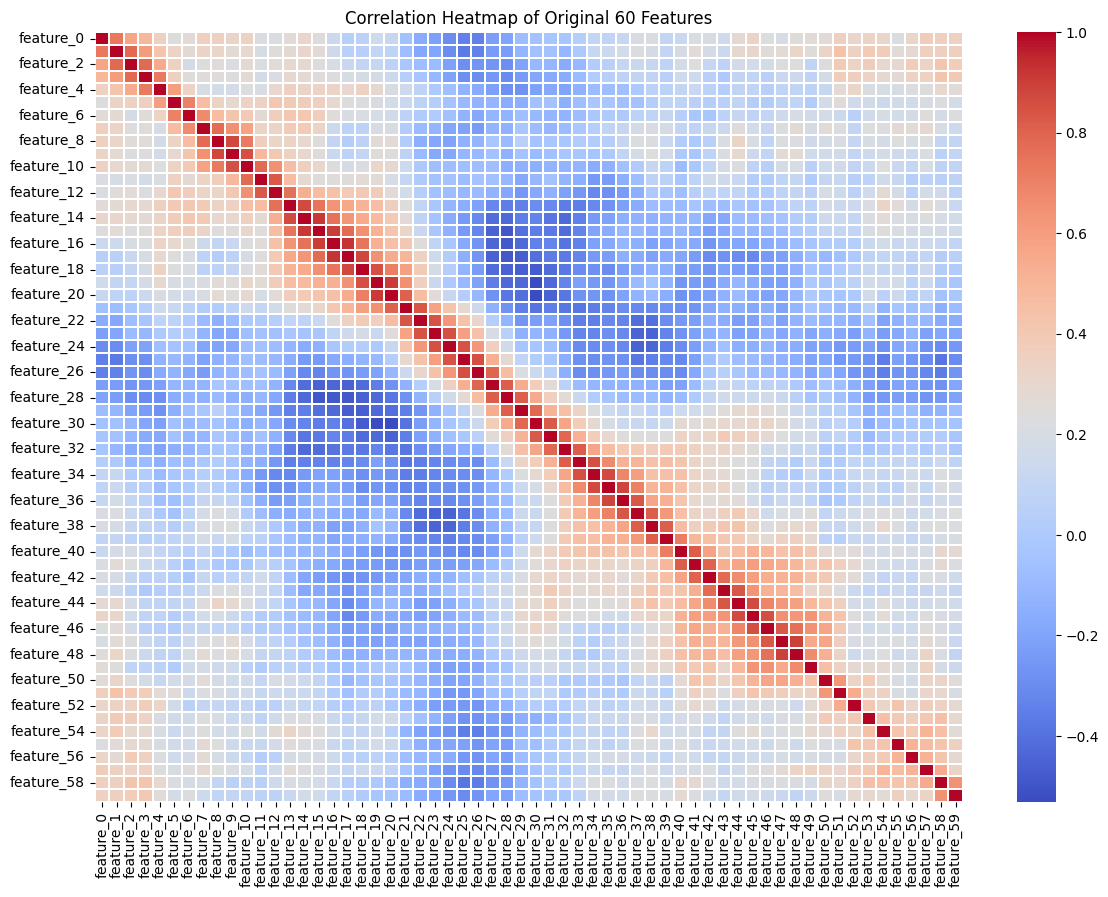

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.iloc[:, :60].corr(), cmap='coolwarm', linewidths=0.1)
plt.title("Correlation Heatmap of Original 60 Features")
plt.show()


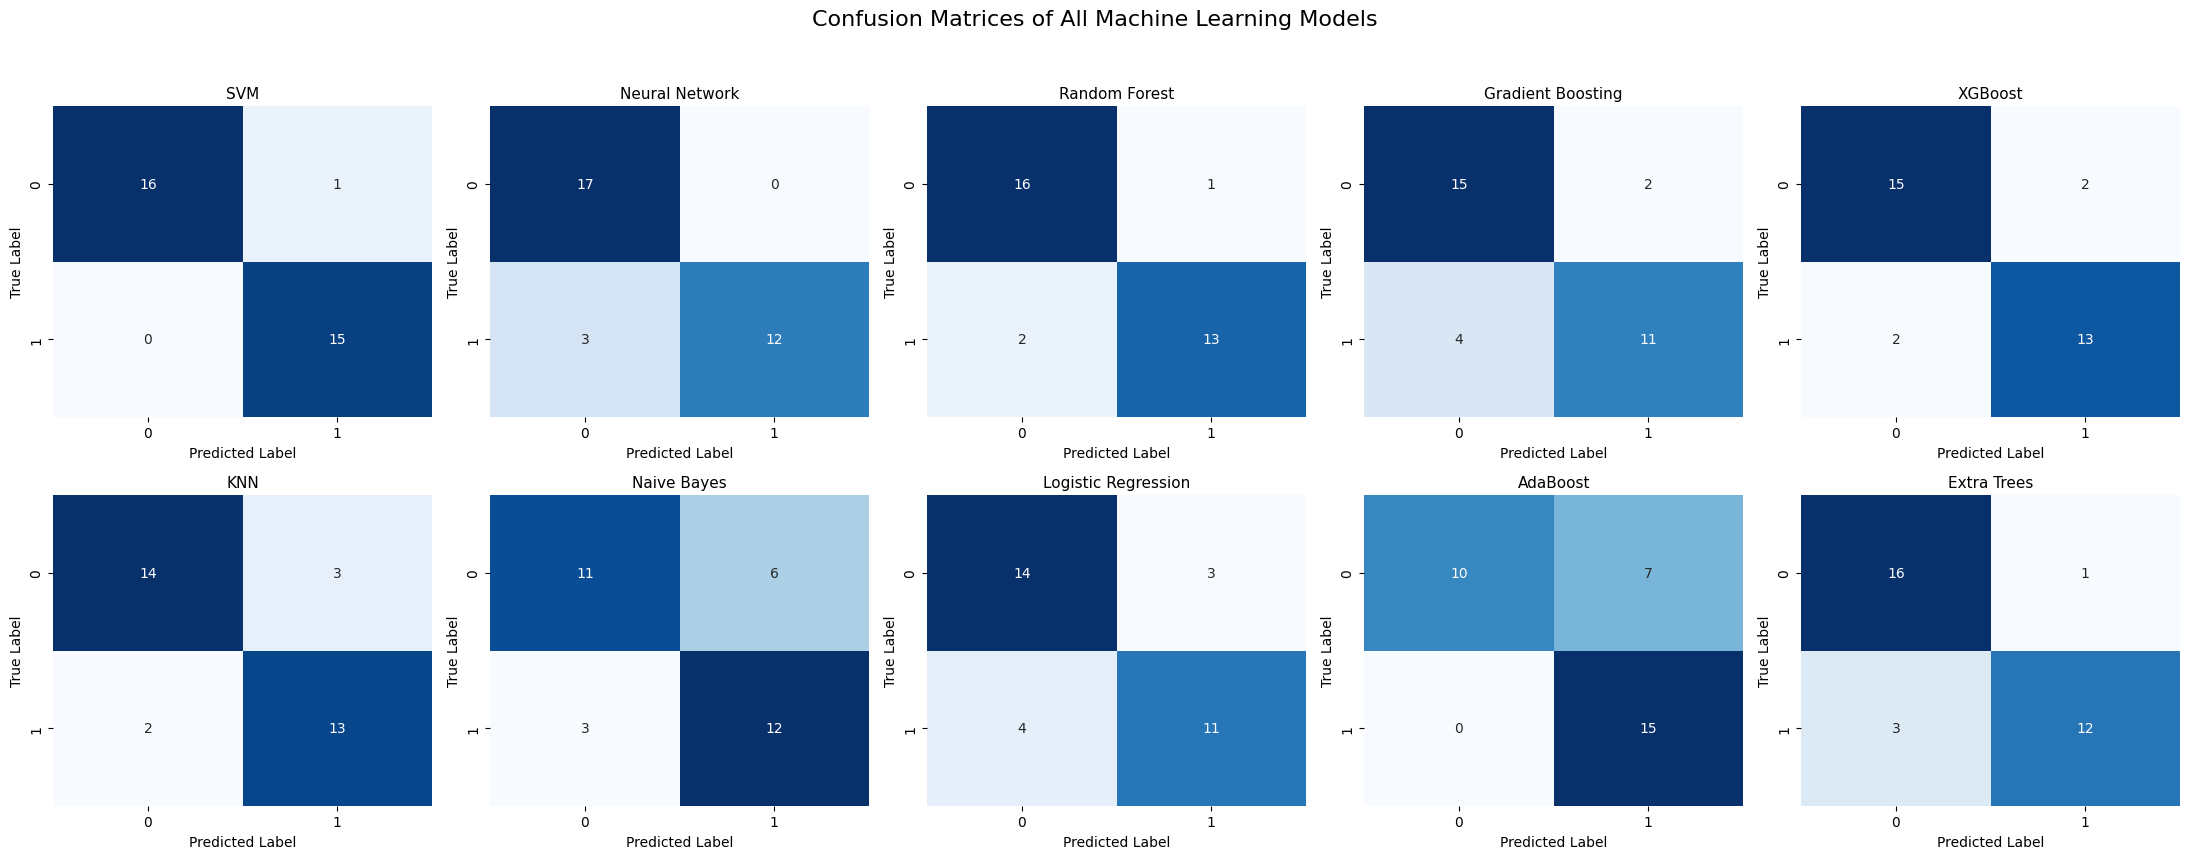

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[idx]
    )

    axes[idx].set_title(name, fontsize=11)
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.suptitle("Confusion Matrices of All Machine Learning Models", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


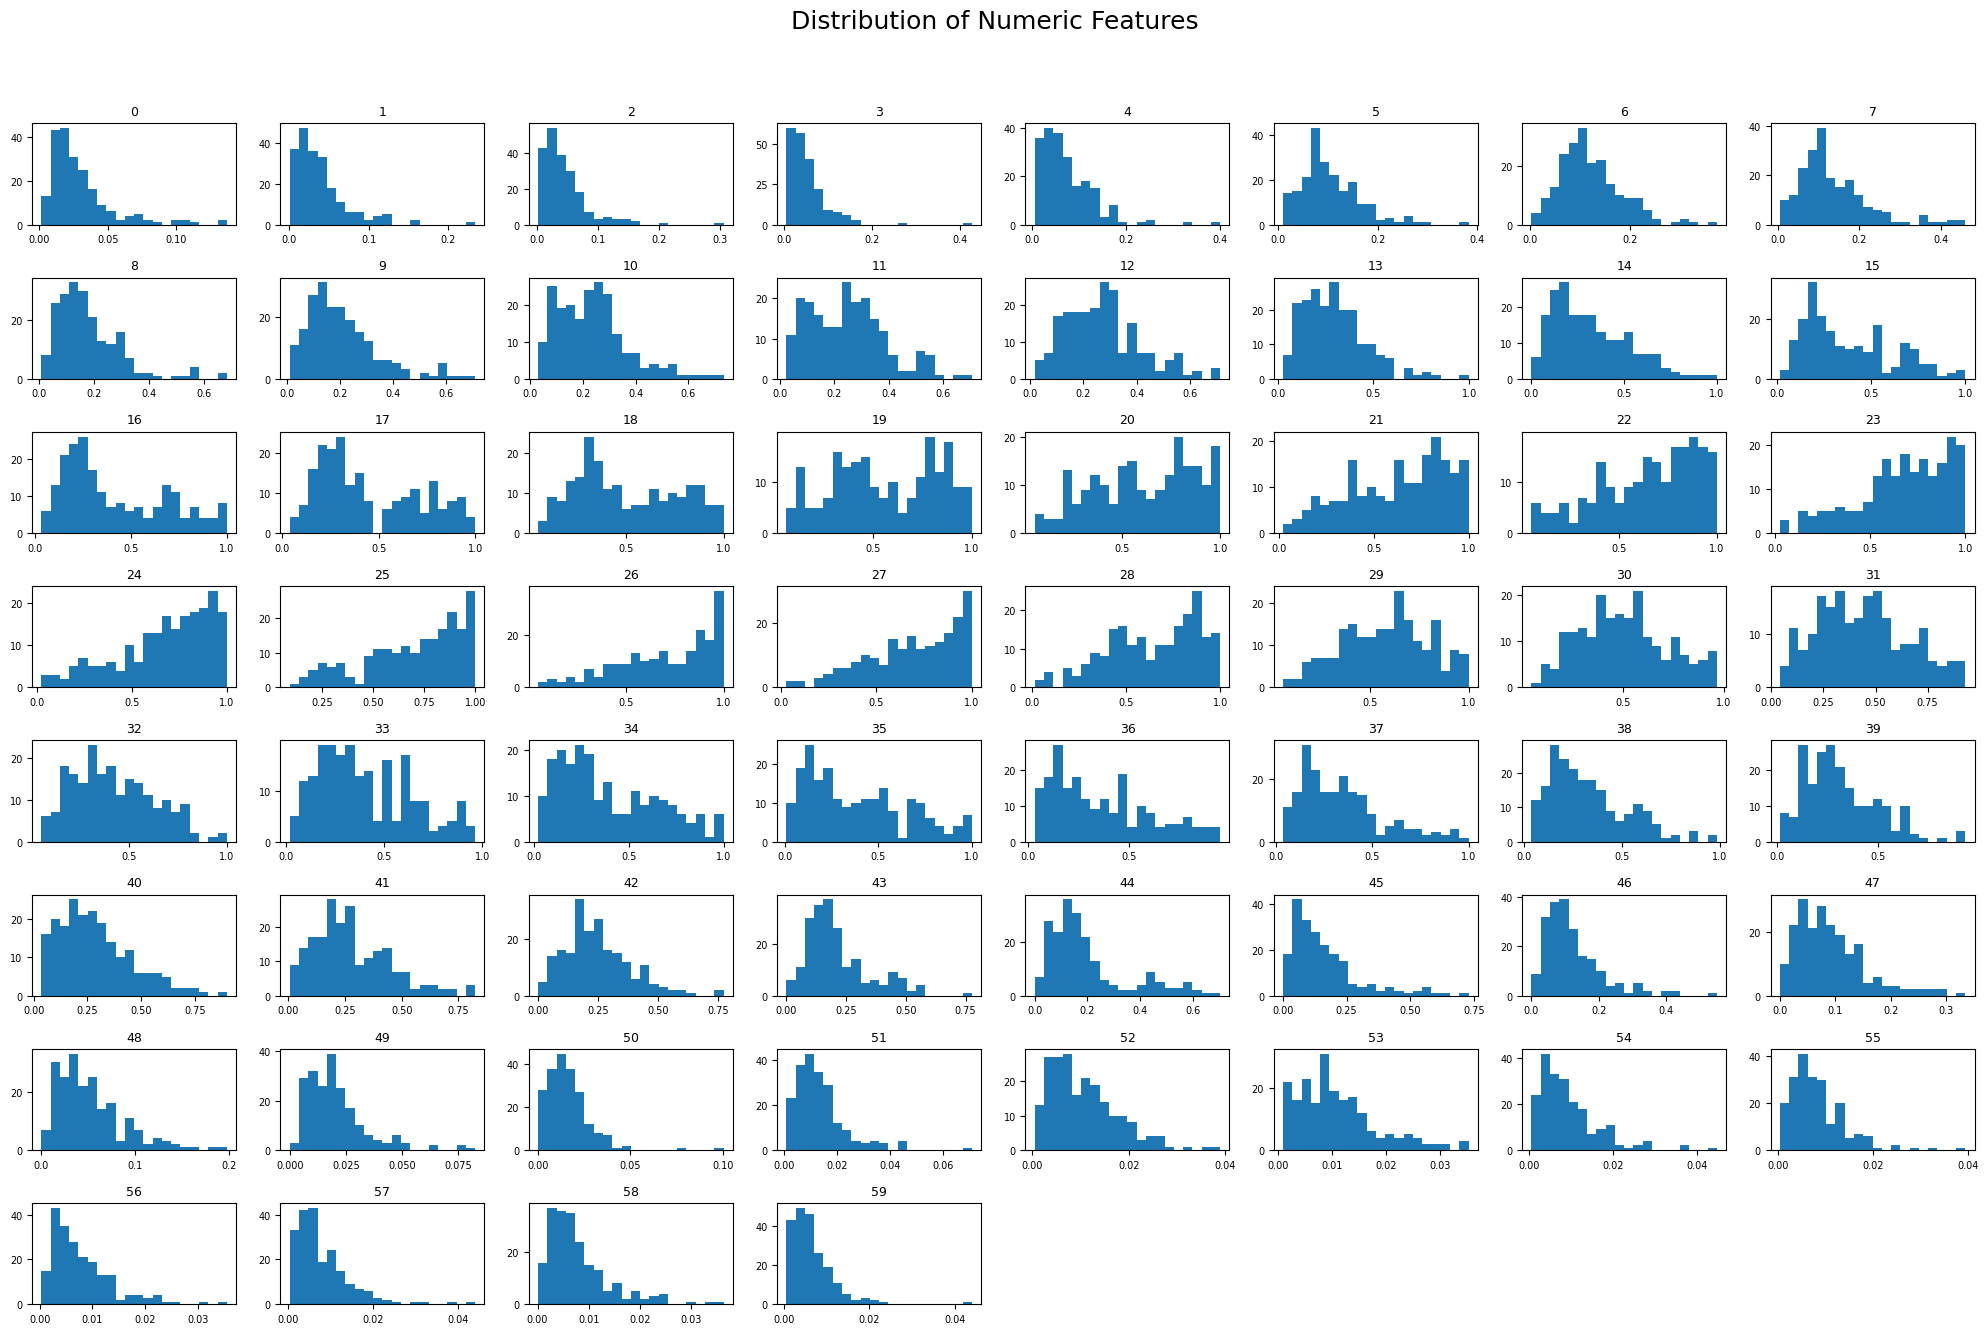

In [16]:
X_features = X.values 
n_features = X_features.shape[1]
n_cols = 8
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(20, 14))

for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(X_features[:, i], bins=20)
    plt.title(f"{i}", fontsize=9)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)

plt.suptitle("Distribution of Numeric Features", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


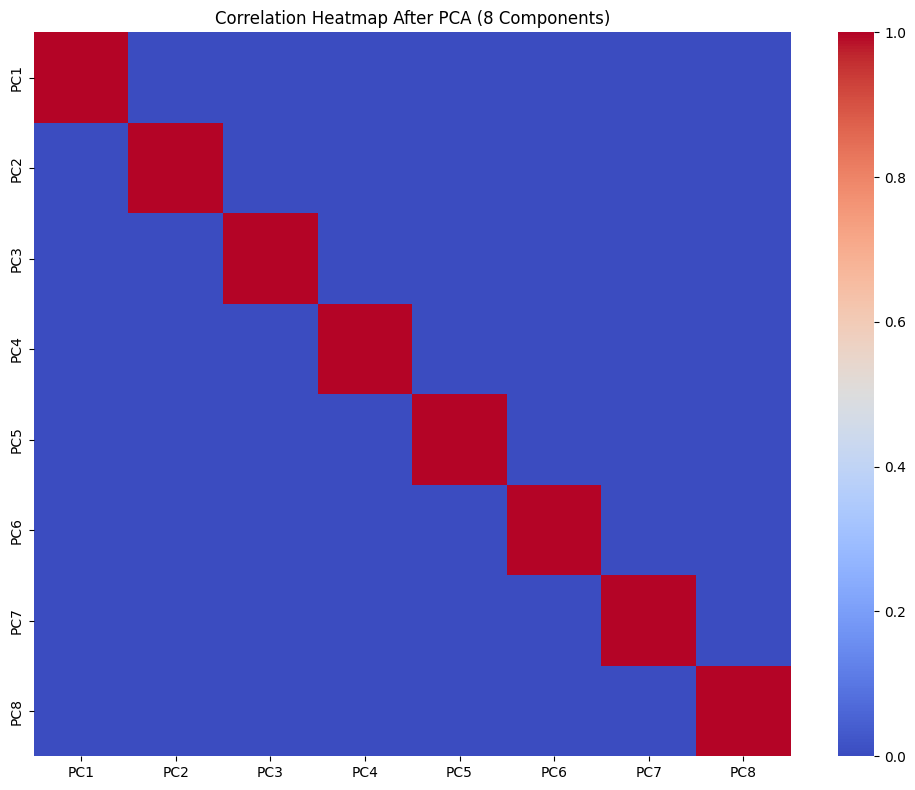

In [17]:
pca_df = pd.DataFrame(X_train, columns=[f"PC{i+1}" for i in range(8)])

plt.figure(figsize=(10, 8))
sns.heatmap(pca_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap After PCA (8 Components)")
plt.tight_layout()
plt.show()

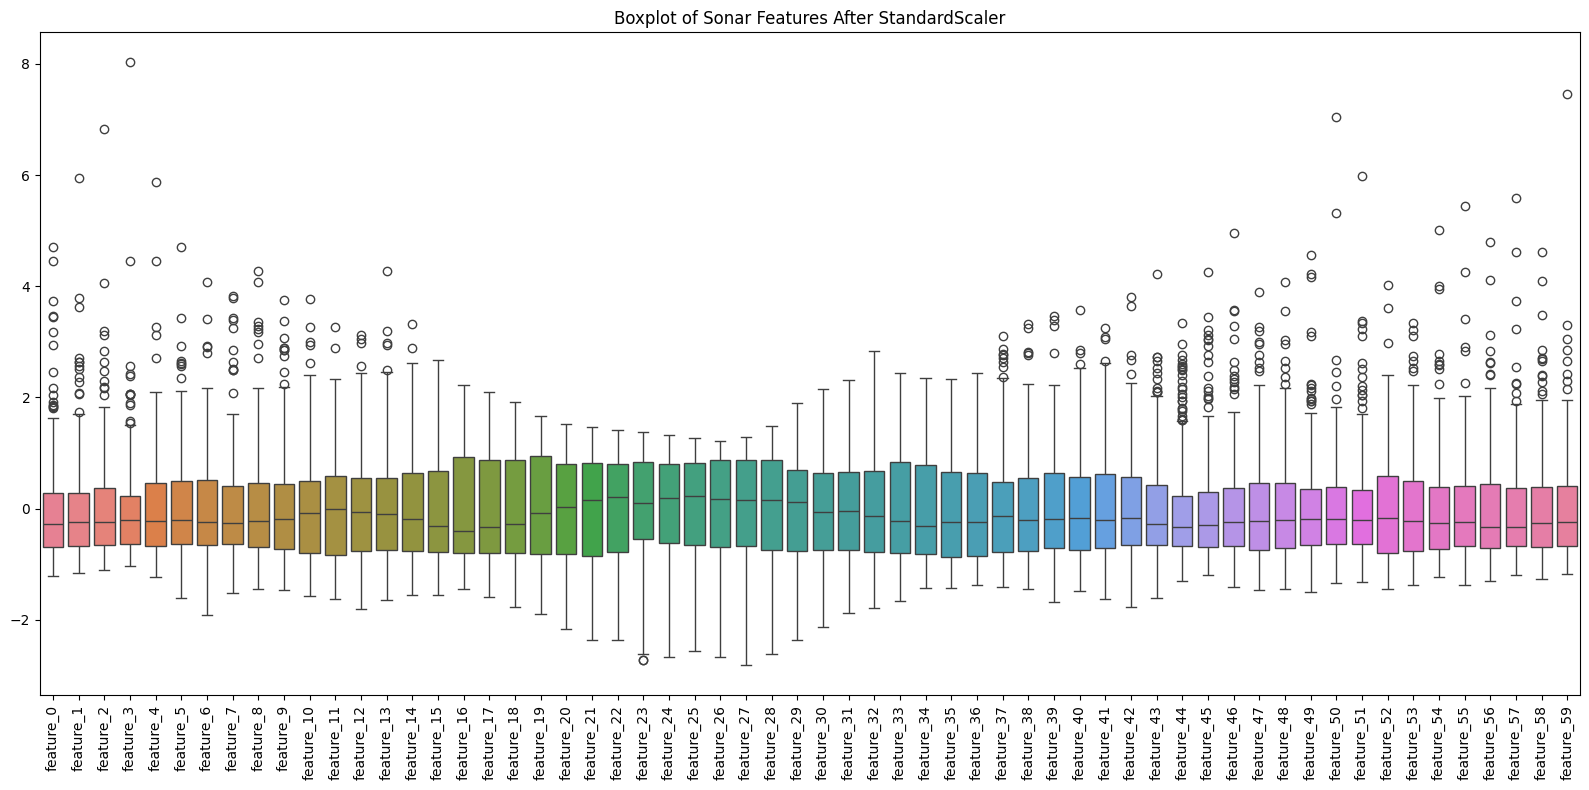

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


plt.figure(figsize=(16, 8))
sns.boxplot(data=pd.DataFrame(X_scaled, columns=X.columns))
plt.title("Boxplot of Sonar Features After StandardScaler")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


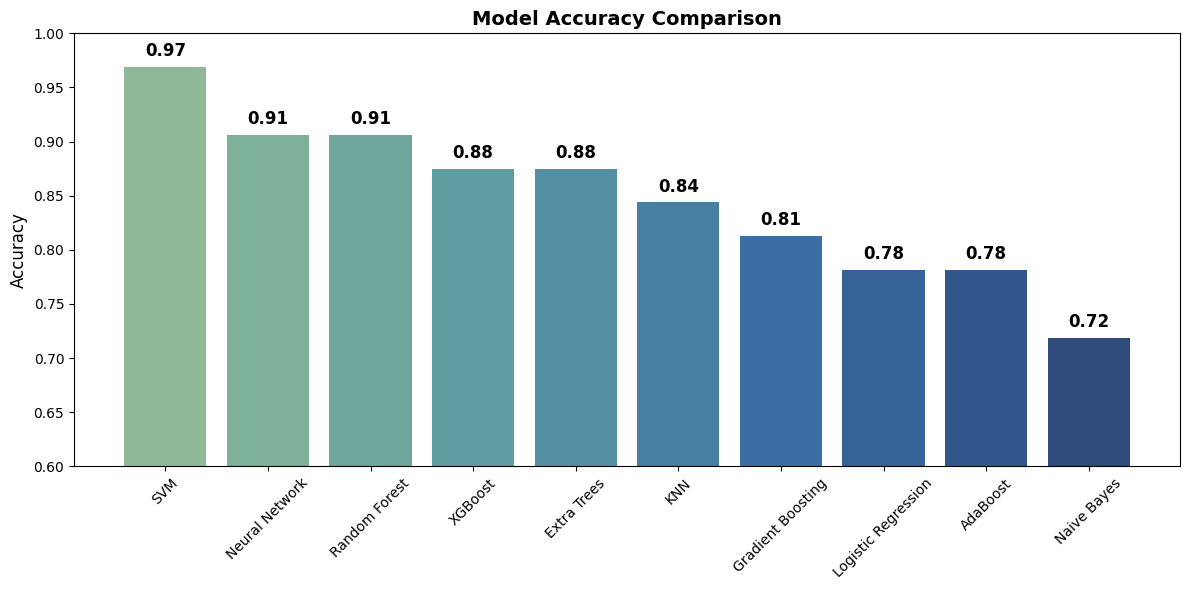

In [19]:
from matplotlib.colors import LinearSegmentedColormap

model_names = [name for name, acc in results]
model_scores = [acc for name, acc in results]

sorted_pairs = sorted(zip(model_names, model_scores),
                      key=lambda x: x[1],
                      reverse=True)

model_names = [x[0] for x in sorted_pairs]
model_scores = [x[1] for x in sorted_pairs]

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_green_blue",
    ["#8fb996", "#5f9ea0", "#3b6ea5", "#2f4b7c"]
)

colors = [custom_cmap(i / (len(model_names)-1)) for i in range(len(model_names))]

plt.figure(figsize=(12, 6))

bars = plt.bar(model_names, model_scores, color=colors)

for i, score in enumerate(model_scores):
    plt.text(i, score + 0.01,
             f"{score:.2f}",
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.6, 1.0)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

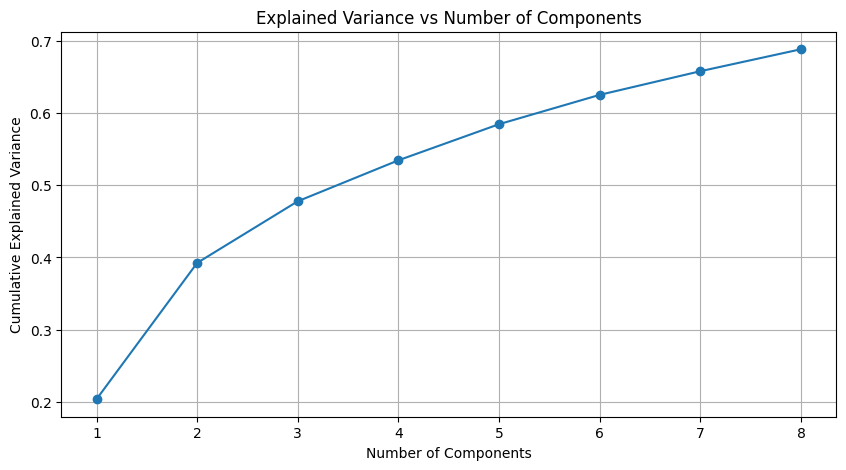

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=8)
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
components = range(1, 9)

plt.figure(figsize=(10, 5))
plt.plot(components, cumulative_variance, marker='o')
plt.title("Explained Variance vs Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(components)
plt.grid(True)
plt.show()

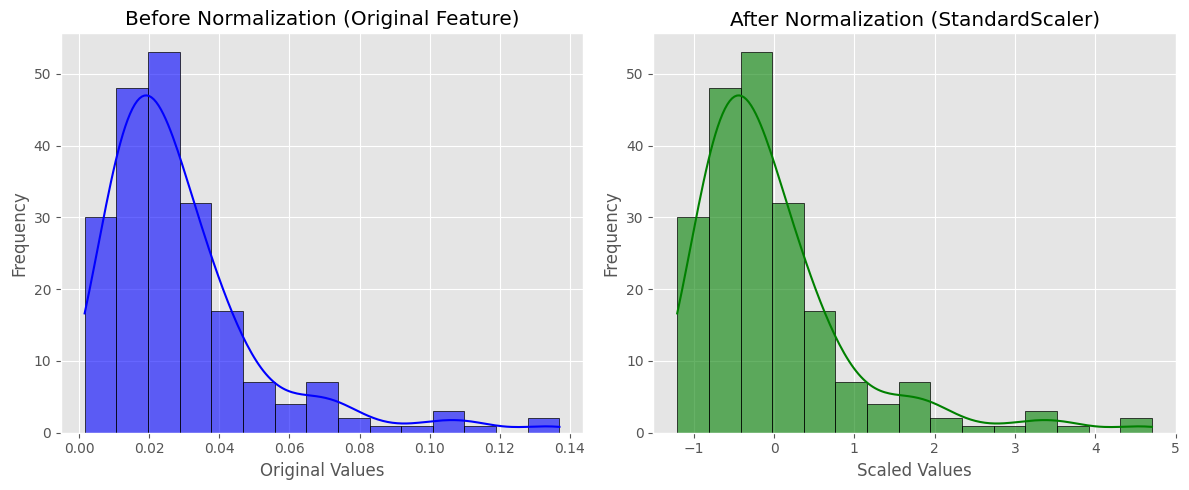

In [ ]:

feature_index = 0
original_feature = X.iloc[:, feature_index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_feature = X_scaled[:, feature_index]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(original_feature,
             bins=15,
             kde=True,
             color='blue',
             edgecolor='black',
             alpha=0.6)

plt.title("Before Normalization (Original Feature)")
plt.xlabel("Original Values")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(scaled_feature,
             bins=15,
             kde=True,
             color='green',
             edgecolor='black',
             alpha=0.6)

plt.title("After Normalization (StandardScaler)")
plt.xlabel("Scaled Values")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()